In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
from src.optimization import optimize_max_sharpe, optimize_min_volatility, optimize_risk, portfolio_performance
from src.data_loader import load_prices
from pypfopt import expected_returns, risk_models

In [2]:
tickers=["SPY", "QQQ", "AAPL", "TLT", "MSFT"]
df=load_prices(tickers, "2020-01-01", "2024-12-31", save=False)
Exp_returns=expected_returns.mean_historical_return(df)
Cov_matrix=risk_models.CovarianceShrinkage(df).ledoit_wolf()

[*********************100%***********************]  5 of 5 completed


In [3]:
H_weights=[]
H_returns=[]
H_volatility=[]
H_sharpe=[]
for n in range(0,5000):
    weights=np.random.random(5)
    weights=weights/weights.sum()
    H_weights.append(weights)
    returns=weights@Exp_returns
    H_returns.append(returns)
    volatility=np.sqrt(weights@Cov_matrix@weights)
    H_volatility.append(volatility)
    sharpe=(returns-0.04)/volatility
    H_sharpe.append(sharpe)


In [4]:
results=pd.DataFrame({
    'Return':H_returns,
    'Volatility':H_volatility,
    'Sharpe':H_sharpe
})

Msharpe=optimize_max_sharpe(df)
return_Msharpe,volatility_Msharpe,sharpe_Msharpe=portfolio_performance(df,Msharpe)
Msharpe={k:v for k,v in Msharpe.items() if v>0}

minvol=optimize_min_volatility(df)
return_minvol,volatility_minvol,sharpe_minvol=portfolio_performance(df,minvol)
minvol={k:v for k,v in minvol.items() if v>0}

Optrisk=optimize_risk(df)
return_Optrisk,volatility_Optrisk,sharpe_Optrisk=portfolio_performance(df,Optrisk)
Optrisk={k:v for k,v in Optrisk.items() if v>0}


Expected annual return: 27.6%
Annual volatility: 30.6%
Sharpe Ratio: 0.77
Expected annual return: 2.7%
Annual volatility: 12.7%
Sharpe Ratio: -0.10
Expected annual return: 9.2%
Annual volatility: 15.0%
Sharpe Ratio: 0.35


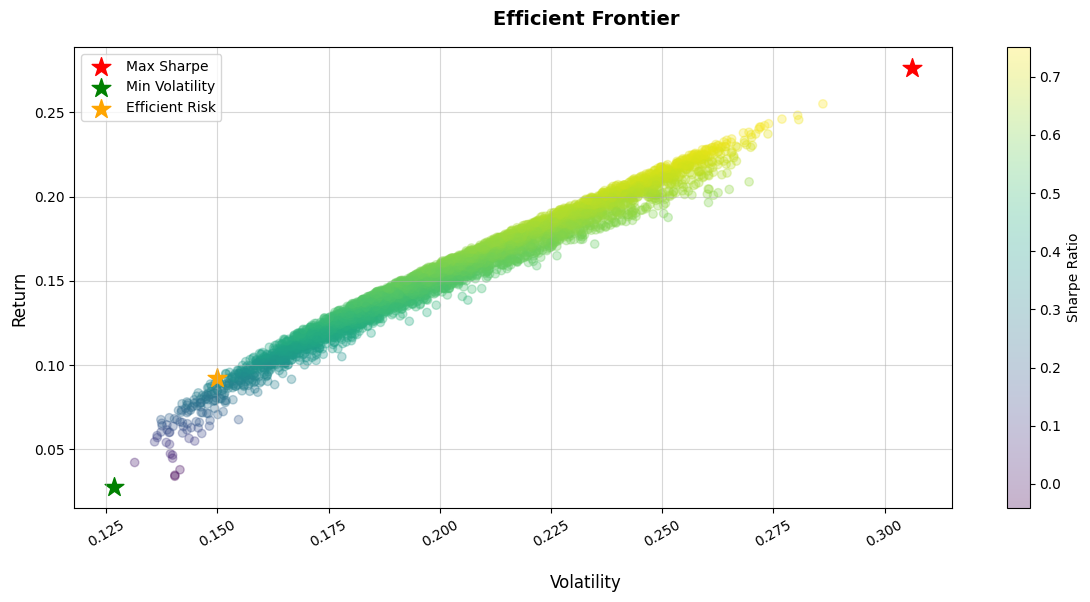

In [5]:
fig,ax=plt.subplots(figsize=(12,6))
fig.suptitle("Efficient Frontier", fontsize=14, fontweight="bold")

scatter=ax.scatter(results['Volatility'],results['Return'],c=results['Sharpe'],cmap='viridis',alpha=0.3)
plt.colorbar(scatter,ax=ax,label='Sharpe Ratio')
ax.scatter(volatility_Msharpe,return_Msharpe,marker='*',s=200,color='red',label='Max Sharpe')
ax.scatter(volatility_minvol,return_minvol,marker='*',s=200,color='green',label='Min Volatility')
ax.scatter(volatility_Optrisk,return_Optrisk,marker='*',s=200,color='orange',label='Efficient Risk')
ax.legend()
fig.supxlabel("Volatility")
fig.supylabel("Return")
ax.tick_params(axis="x",rotation=30)
ax.grid(True,alpha=0.5)
plt.tight_layout()
plt.show()

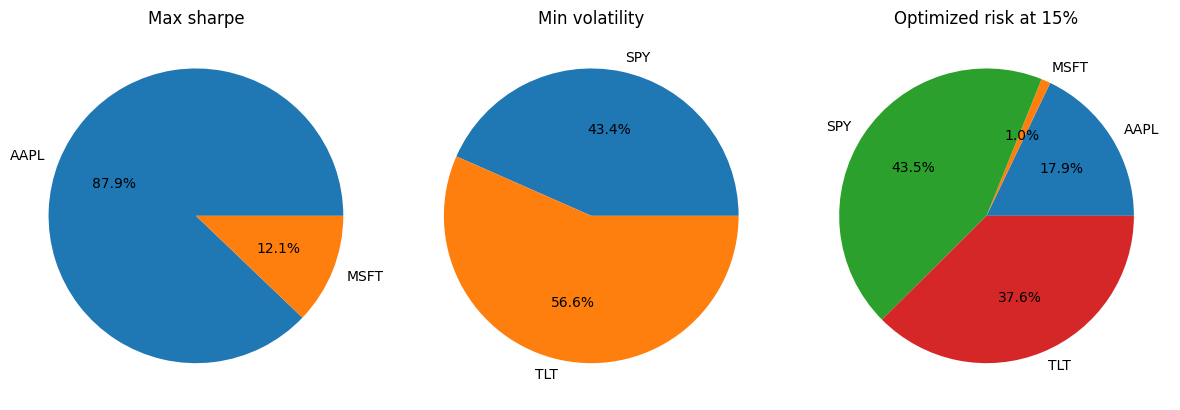

In [6]:
fig,ax=plt.subplots(1,3,figsize=(12, 6))
ax[0].pie(Msharpe.values(),labels=Msharpe.keys(),autopct='%1.1f%%')
ax[0].set_title('Max sharpe')
ax[1].pie(minvol.values(),labels=minvol.keys(),autopct='%1.1f%%')
ax[1].set_title('Min volatility')
ax[2].pie(Optrisk.values(),labels=Optrisk.keys(),autopct='%1.1f%%')
ax[2].set_title('Optimized risk at 15%')

plt.tight_layout()
plt.show()